In [ ]:
#https://towardsdatascience.com/making-a-trade-call-using-simple-moving-average-sma-crossover-strategy-python-implementation-29963326da7a
#https://medium.com/codex/algorithmic-trading-with-sma-in-python-7d66008d37b1
#https://towardsdatascience.com/python-how-to-get-live-market-data-less-than-0-1-second-lag-c85ee280ed93

In [89]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [90]:
data = yf.download(tickers='QQQ',period='1y',interval='1h')
data

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
2021-10-15 09:30:00-04:00,367.880005,368.160004,366.820007,366.936890,366.936890,9299421
2021-10-15 10:30:00-04:00,366.940002,368.630005,366.940002,368.260010,368.260010,4518931
2021-10-15 11:30:00-04:00,368.250000,368.409912,367.125000,367.799988,367.799988,6898740
2021-10-15 12:30:00-04:00,367.799988,368.140015,367.579987,367.799988,367.799988,3794769
2021-10-15 13:30:00-04:00,367.809998,368.528015,367.804993,368.399994,368.399994,2355215
...,...,...,...,...,...,...
2022-10-14 12:30:00-04:00,262.769989,263.515015,261.829987,262.549988,262.549988,6513897
2022-10-14 13:30:00-04:00,262.540009,263.250000,261.260010,261.750000,261.750000,5179900
2022-10-14 14:30:00-04:00,261.720001,262.450012,261.010010,261.679993,261.679993,5896436
2022-10-14 15:30:00-04:00,261.690002,262.191193,260.140015,260.630005,260.630005,8922831


In [91]:
def EMA(data):
    data['EMA5'] = data.Close.ewm(span=5).mean()
    data['EMA20'] = data.Close.ewm(span=20).mean()
    data['EMA100'] = data.Close.ewm(span=100).mean()
    
data.head(EMA(data))    

,Open,High,Low,Close,Adj Close,Volume,EMA5,EMA20,EMA100
2021-10-15 09:30:00-04:00,367.880005,368.160004,366.820007,366.936890,366.936890,9299421,366.936890,366.936890,366.936890
2021-10-15 10:30:00-04:00,366.940002,368.630005,366.940002,368.260010,368.260010,4518931,367.730762,367.631528,367.605065
2021-10-15 11:30:00-04:00,368.250000,368.409912,367.125000,367.799988,367.799988,6898740,367.763553,367.693385,367.671343
2021-10-15 12:30:00-04:00,367.799988,368.140015,367.579987,367.799988,367.799988,3794769,367.778687,367.724160,367.704476
2021-10-15 13:30:00-04:00,367.809998,368.528015,367.804993,368.399994,368.399994,2355215,368.017198,367.887638,367.849198
...,...,...,...,...,...,...,...,...,...
2022-10-14 12:30:00-04:00,262.769989,263.515015,261.829987,262.549988,262.549988,6513897,264.134130,265.125921,272.604955
2022-10-14 13:30:00-04:00,262.540009,263.250000,261.260010,261.750000,261.750000,5179900,263.339420,264.804405,272.390005
2022-10-14 14:30:00-04:00,261.720001,262.450012,261.010010,261.679993,261.679993,5896436,262.786277,264.506842,272.177926
2022-10-14 15:30:00-04:00,261.690002,262.191193,260.140015,260.630005,260.630005,8922831,262.067520,264.137619,271.949254


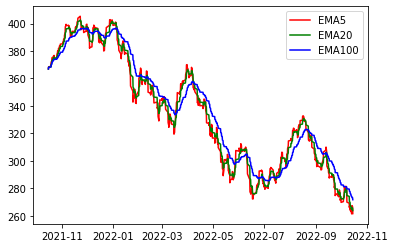

In [92]:
plt.plot(data.EMA5, label='EMA5', color='red')
plt.plot(data.EMA20, label='EMA20', color='green')
plt.plot(data.EMA100, label='EMA100', color='blue')
plt.legend()
plt.show()

In [93]:
Buy, Sell = [], []

for i in range (2,len(data)):

    if data.EMA5.iloc[i] > data.EMA20.iloc[i] > data.EMA100.iloc[i]  and data.EMA5.iloc[i-1] < data.EMA20.iloc[i-1] > data.EMA100.iloc[i-1]:
        Buy.append(i)
        
    if data.EMA5.iloc[i] < data.EMA20.iloc[i]  and data.EMA5.iloc[i-1] > data.EMA20.iloc[i-1]: 
        Sell.append(i)

In [94]:
Buy

[43, 142, 210, 270, 379, 817, 1117, 1127, 1363, 1433, 1479]

In [95]:
Realbuys = [i+1 for i in Buy]
Realsells = [i+1 for i in Sell]

In [96]:
Buyprices = data.Open.iloc[Realbuys]
Sellprices = data.Open.iloc[Realsells]

In [97]:
if Sellprices.index[0] < Buyprices.index[0]:
    Sellprices = Sellprices.drop(Sellprices.index[0])
    
elif Buyprices.index[-1] > Sellprices.index[-1]:
    Buyprices = Buyprices.drop(Sellprices.index[-1])    

In [98]:
profitsrel = []

for i in range(len(Buyprices)):
    profitsrel.append((Sellprices[i]-Buyprices[i])/Buyprices[i])

In [99]:
profit = sum(profitsrel)
print (profit)

1.1591565032871738
